"""
# Análisis de Componentes Principales (PCA) en el Conjunto de Datos Iris

## Introducción
El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que permite identificar patrones en los datos y extraer la información más relevante minimizando la pérdida de información.

En este estudio, aplicaremos PCA al conjunto de datos **Iris**, que contiene mediciones de longitud y ancho de sépalos y pétalos de tres especies de flores (*setosa, versicolor y virginica*).

### Objetivo
Reducir la dimensionalidad de los datos de Iris y visualizar si PCA permite separar las especies en un espacio de menor dimensión.

## Descripción del Conjunto de Datos
El dataset Iris contiene:
- **4 variables**:
  - Longitud del sépalo (cm)
  - Ancho del sépalo (cm)
  - Longitud del pétalo (cm)
  - Ancho del pétalo (cm)
- **150 observaciones** (50 por cada especie de flor)
- **1 variable categórica**: especie de la flor (*setosa, versicolor, virginica*)
"""


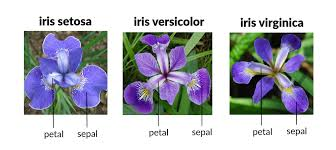

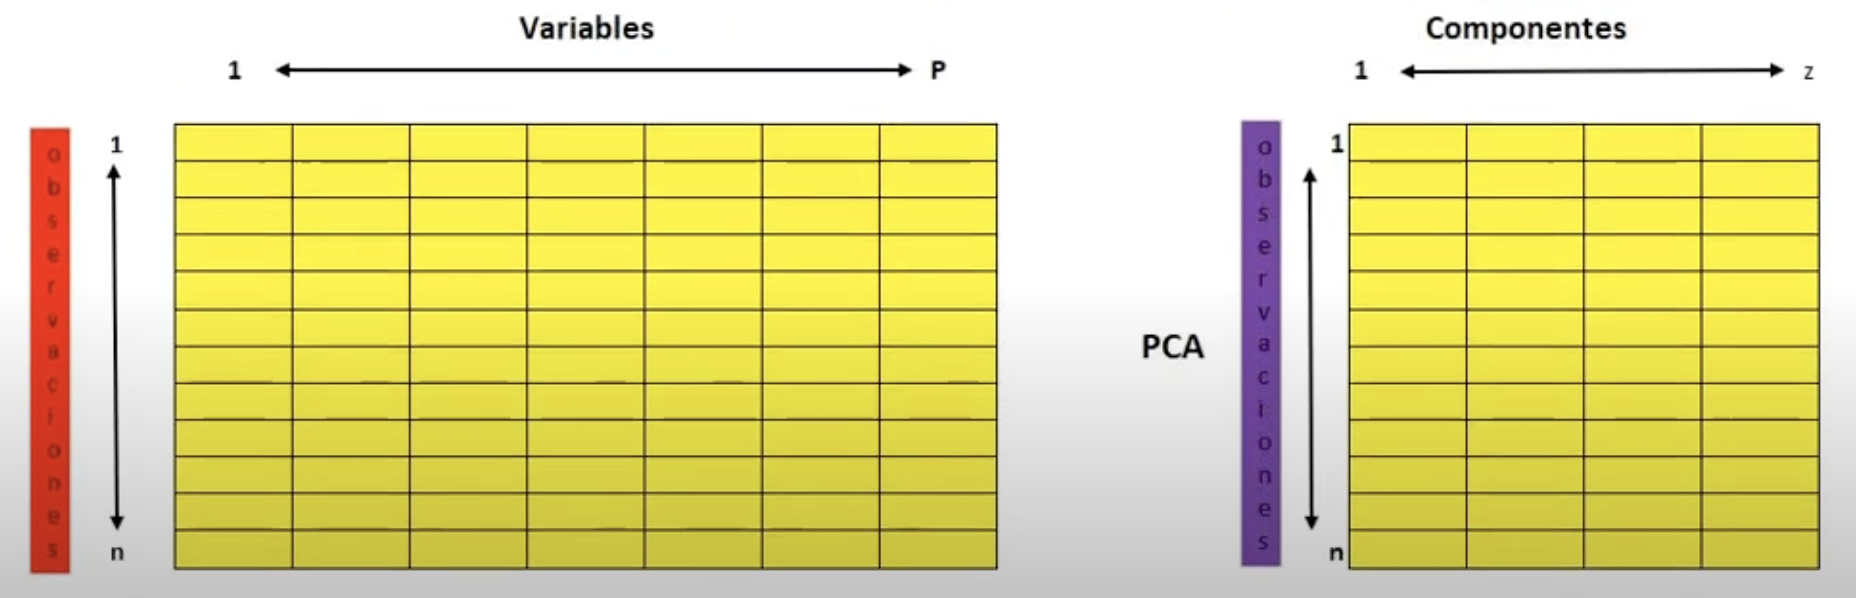

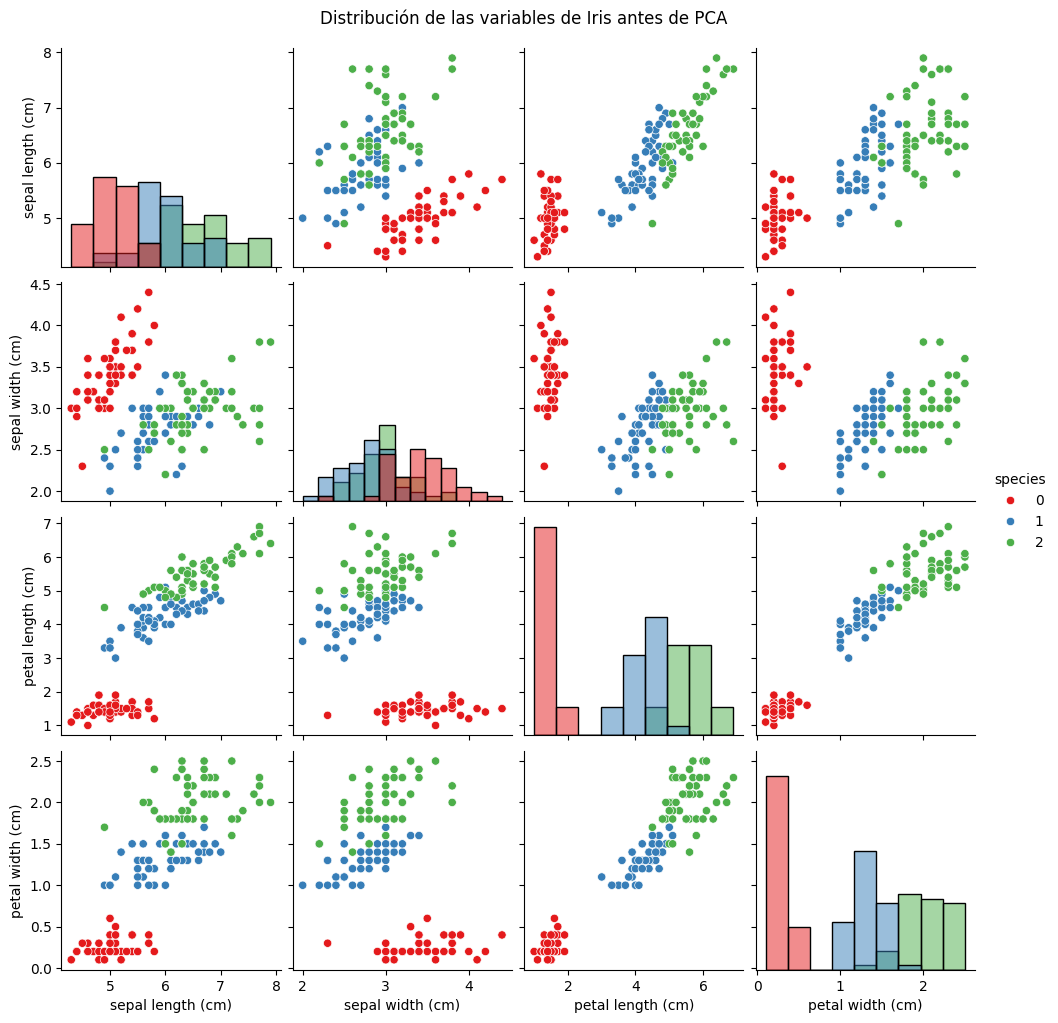

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Cargar el conjunto de datos Iris
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data["species"] = iris.target
species_names = list(iris.target_names)

# Visualización general de los datos antes de PCA
sns.pairplot(data, hue="species", palette="Set1", diag_kind="hist")
plt.suptitle("Distribución de las variables de Iris antes de PCA", y=1.02)
plt.show()



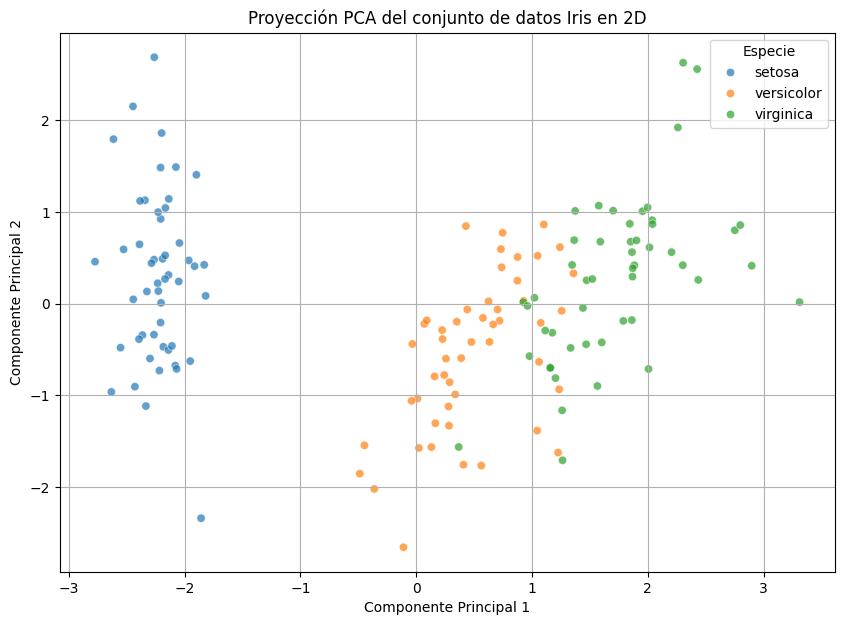

In [ ]:
# Normalización de los datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:, :-1])

# Aplicación de PCA con dos componentes principales
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

# Crear un DataFrame con los resultados de PCA
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["species"] = data["species"]


# Visualización en 2D después de PCA
plt.figure(figsize=(10,7))
sns.scatterplot(x=pca_df["PC1"], y=pca_df["PC2"], hue=pca_df["species"], palette="tab10", alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Proyección PCA del conjunto de datos Iris en 2D")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=species_names, title="Especie")
plt.grid()
plt.show()


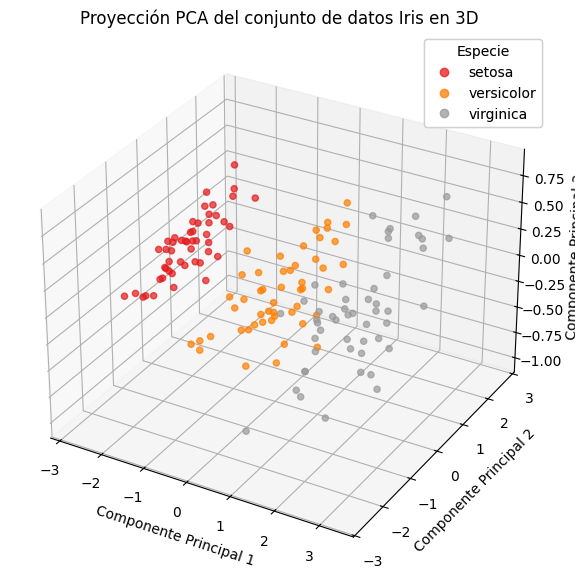

In [ ]:

# Aplicación de PCA con tres componentes principales para visualizar en 3D
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(data_scaled)

# Visualización de los grupos en el espacio PCA en 3D
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pca_result_3d[:, 0], pca_result_3d[:, 1], pca_result_3d[:, 2], c=data["species"], cmap="Set1", alpha=0.7)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.set_zlabel("Componente Principal 3")
ax.set_title("Proyección PCA del conjunto de datos Iris en 3D")
legend_labels = [species_names[i] for i in range(len(species_names))]
legend = plt.legend(handles=sc.legend_elements()[0], labels=legend_labels, title="Especie")
ax.add_artist(legend)
plt.show()



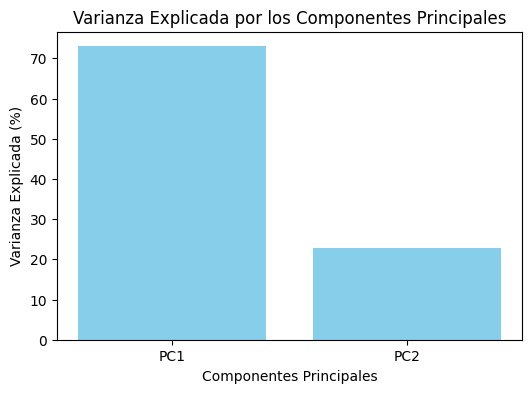

Varianza explicada por cada componente:
[0.72962445 0.22850762]


In [ ]:
# Visualización de la varianza explicada
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
plt.bar([1,2], explained_variance*100, tick_label=["PC1", "PC2"], color='skyblue')
plt.xlabel("Componentes Principales")
plt.ylabel("Varianza Explicada (%)")
plt.title("Varianza Explicada por los Componentes Principales")
plt.show()

print("Varianza explicada por cada componente:")
print(explained_variance)

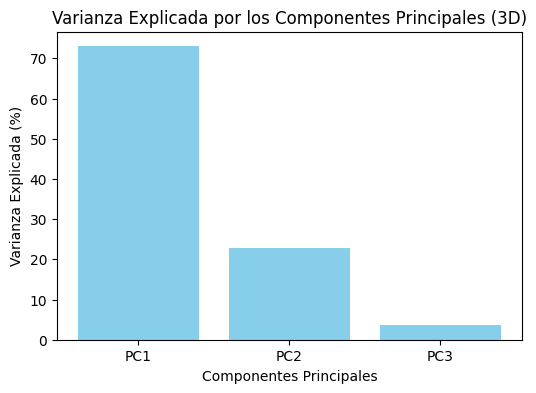

Varianza explicada por cada componente:
[0.72962445 0.22850762 0.03668922]


In [ ]:

# Visualización de la varianza explicada para 3 componentes
explained_variance = pca_3d.explained_variance_ratio_
plt.figure(figsize=(6,4))
plt.bar([1,2,3], explained_variance*100, tick_label=["PC1", "PC2", "PC3"], color='skyblue')
plt.xlabel("Componentes Principales")
plt.ylabel("Varianza Explicada (%)")
plt.title("Varianza Explicada por los Componentes Principales (3D)")
plt.show()

print("Varianza explicada por cada componente:")
print(explained_variance)


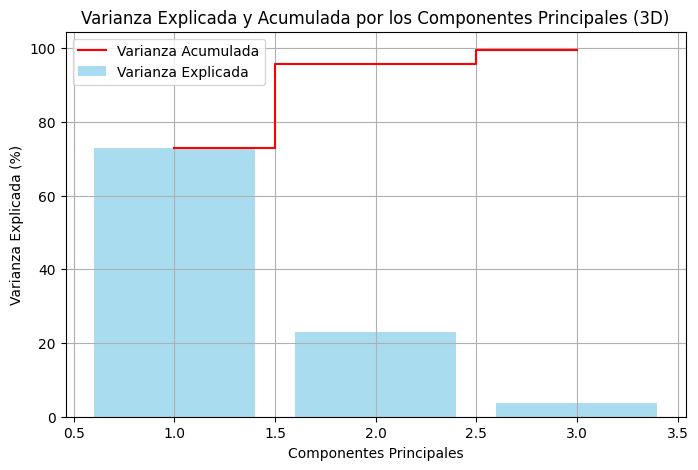

Varianza explicada por cada componente:
[0.72962445 0.22850762 0.03668922]
Varianza acumulada:
[0.72962445 0.95813207 0.99482129]


In [ ]:
# Visualización de la varianza explicada y acumulada
explained_variance = pca_3d.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.bar(range(1, 4), explained_variance*100, alpha=0.7, align='center', label='Varianza Explicada', color='skyblue')
plt.step(range(1, 4), cumulative_variance*100, where='mid', label='Varianza Acumulada', color='red')
plt.xlabel("Componentes Principales")
plt.ylabel("Varianza Explicada (%)")
plt.title("Varianza Explicada y Acumulada por los Componentes Principales (3D)")
plt.legend()
plt.grid()
plt.show()

print("Varianza explicada por cada componente:")
print(explained_variance)
print("Varianza acumulada:")
print(cumulative_variance)